<a href="https://colab.research.google.com/github/UHgroup16/Data-Science-Challenge/blob/main/global_knn_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
df_train = pd.read_csv('/content/drive/MyDrive/Data Science Challenge/dataset_B_training.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Data Science Challenge/dataset_B_testing.csv')

In [18]:
target_col = "h1n1_vaccine"

y = df_train[target_col]

# remove target from train features
X = df_train.drop(columns=[target_col])

In [19]:
train_ids = X["respondent_id"]
test_ids = df_test["respondent_id"]

# remove IDs for ML
X = X.drop(columns=["respondent_id"])
df_test_features = df_test.drop(columns=["respondent_id"])

EDA

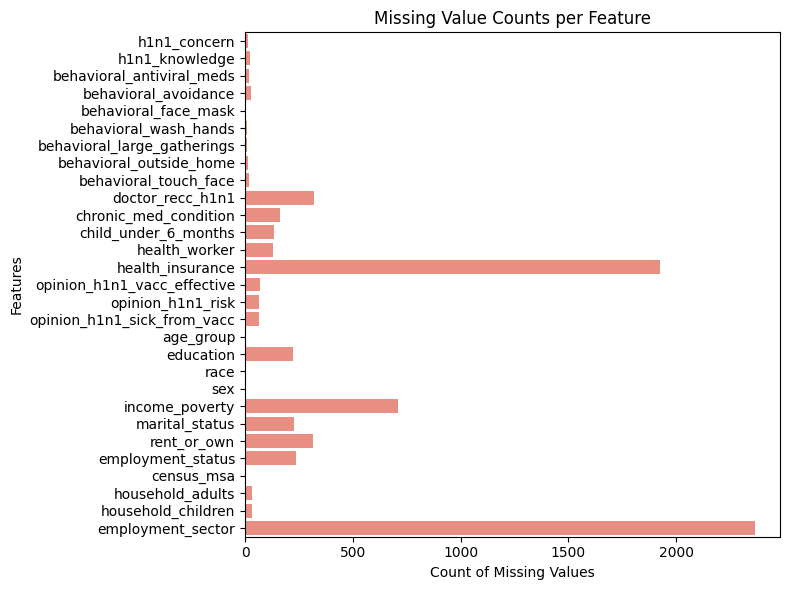

In [20]:
# visualise missing value counts
missing_counts = X.isnull().sum()
plt.figure(figsize=(8, 6))
sns.barplot(y=missing_counts.index, x=missing_counts.values, orient='h', color='salmon')
plt.yticks(rotation=0)
plt.title("Missing Value Counts per Feature")
plt.ylabel("Features")
plt.xlabel("Count of Missing Values")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Class Distribution of H1N1 Vaccine Target')

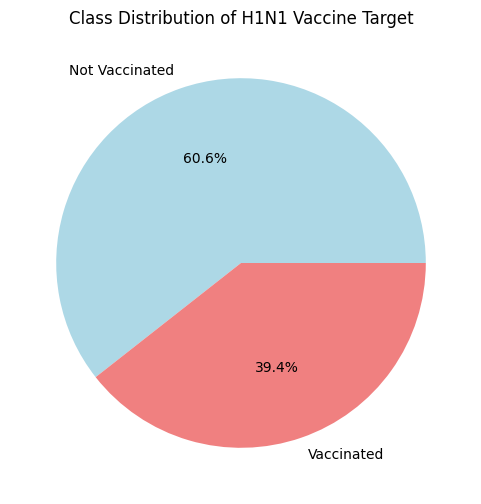

In [21]:
#visualise class balance percentagage pie chart with font and color edits and labels for 0 and 1
class_counts = y.value_counts()
plt.figure(figsize=(6, 6))
labels = ['Not Vaccinated', 'Vaccinated']
plt.pie(class_counts.values, labels=labels, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title("Class Distribution of H1N1 Vaccine Target")

IMPUTATION AND ENCODING

In [22]:
combined = pd.concat([X, df_test_features], axis=0)


categorical_cols = combined.select_dtypes(include=['object']).columns.tolist()
numeric_cols = combined.select_dtypes(include=[np.number]).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)


Categorical Columns:
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']

Numeric Columns:
['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'household_adults', 'household_children']


In [23]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

combined_cat = combined[categorical_cols].astype(str)

combined_cat_encoded = pd.DataFrame(
    encoder.fit_transform(combined_cat),
    columns=categorical_cols,
    index=combined.index
)

combined_encoded = pd.concat(
    [combined[numeric_cols], combined_cat_encoded],
    axis=1
)

In [24]:
print("\nRunning Global KNN Imputation...")

imputer = KNNImputer(
    n_neighbors=5,
    weights='distance'
)

combined_imputed_array = imputer.fit_transform(combined_encoded)

combined_imputed = pd.DataFrame(
    combined_imputed_array,
    columns=combined_encoded.columns,
    index=combined_encoded.index
)



Running Global KNN Imputation...


In [25]:
X_imputed = combined_imputed.iloc[:len(X), :]
X_test_imputed = combined_imputed.iloc[len(X):, :]

ML MODELLING

In [26]:
from sklearn.metrics import classification_report

X_train, X_val, y_train, y_val = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTraining Random Forest Model...")

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


val_preds = model.predict(X_val)

accuracy = accuracy_score(y_val, val_preds)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, val_preds))


model.fit(X_imputed, y)


Training Random Forest Model...
Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       577
           1       0.71      0.61      0.66       375

    accuracy                           0.75       952
   macro avg       0.74      0.73      0.73       952
weighted avg       0.75      0.75      0.75       952



RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [27]:

test_predictions = model.predict(X_test_imputed)


submission = pd.DataFrame({
    "respondent_id": test_ids,
    "h1n1_vaccine": test_predictions.astype(int)
})


output_path = "h1n1_submission.csv"

submission.to_csv(output_path, index=False)


print(submission.head())

   respondent_id  h1n1_vaccine
0           4757             0
1           4758             0
2           4759             0
3           4760             0
4           4761             0


EXPLAINABLE AI

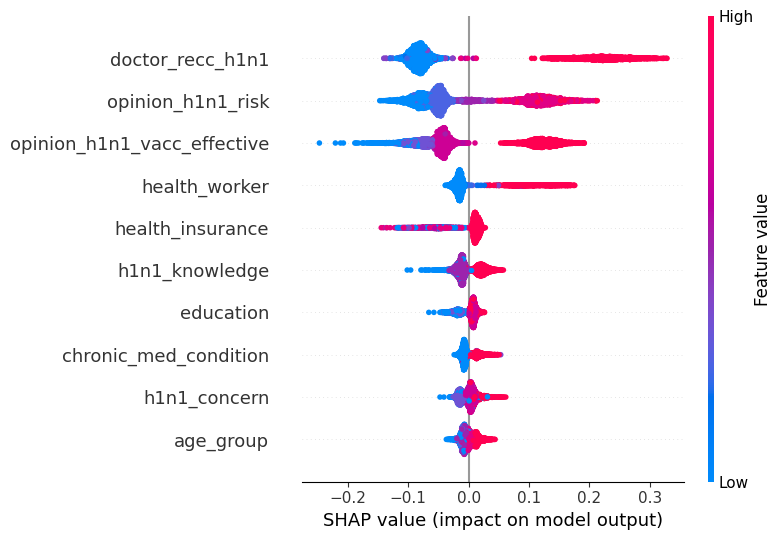

In [28]:
#shapley values and feature importance
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_imputed)

#visualize the SHAP values for the first 10 samples
shap.summary_plot(shap_values[:, :, 1], X_imputed, max_display=10)